In [3]:
# ============================================================
# Core Data Handling and Numerical Computing
# ============================================================

import numpy as np                  # Numerical computing
import pandas as pd                 # Data manipulation and analysis


# ============================================================
# Scikit-Learn: Preprocessing and Pipelines
# ============================================================

from sklearn.compose import ColumnTransformer      # Column-wise preprocessing
from sklearn.pipeline import Pipeline              # ML pipelines
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer           # Missing value handling


# ============================================================
# Scikit-Learn: Model Selection and Validation
# ============================================================

from sklearn.model_selection import (
    train_test_split,               # Train-test splitting
    KFold,                          # K-fold cross-validation
    StratifiedKFold,                # Stratified CV (mainly for classification)
    GridSearchCV,                   # Hyperparameter tuning
    cross_val_score                 # Cross-validation scoring
)


# ============================================================
# Scikit-Learn: Models and Custom Estimators
# ============================================================

from sklearn.linear_model import LinearRegression   # Baseline regression model
from sklearn.base import BaseEstimator, RegressorMixin  # Custom estimator support


# ============================================================
# Scikit-Learn: Evaluation Metrics
# ============================================================

from sklearn.metrics import mean_squared_error, r2_score


# ============================================================
# Visualization and Plotting
# ============================================================

import matplotlib.pyplot as plt     # Core plotting
import seaborn as sns               # Statistical visualization

from IPython.display import Image   # Display images in notebooks

from mlxtend.plotting import (
    scatterplotmatrix,              # Feature relationship plots
    heatmap                         # Correlation heatmaps
)


# ============================================================
# Reproducibility
# ============================================================

from numpy.random import seed        # Set random seed


# ============================================================
# Model Persistence (Saving/Loading Models)
# ============================================================

import pickle                        # Save trained models

In [4]:
df = pd.read_csv('Default.csv')
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [5]:
print("Dataset shape:", df.shape)

Dataset shape: (10000, 4)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  str    
 1   student  10000 non-null  str    
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), str(2)
memory usage: 312.6 KB


In [7]:
df.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729272
max,2654.322576,73554.233495


In [8]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)

Missing values per column:
default    0
student    0
balance    0
income     0
dtype: int64


In [9]:
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print("\nMissing percentage:")
print(missing_pct)


Missing percentage:
default    0.0
student    0.0
balance    0.0
income     0.0
dtype: float64


In [10]:
df['default'] = df['default'].map({'No': 0, 'Yes': 1})
# only encode the target variable here
# ── Verify the conversion ─────────────────────────────────
print(df['default'].unique())     # Expected: [0 1]
print(df['default'].dtype)       # Expected: int64
df.head()

[0 1]
int64


,default,student,balance,income
0,0,No,729.526495,44361.625074
1,0,Yes,817.180407,12106.134700
2,0,No,1073.549164,31767.138947
3,0,No,529.250605,35704.493935
4,0,No,785.655883,38463.495879


In [11]:
print("Class counts:")
print(df['default'].value_counts())

Class counts:
default
0    9667
1     333
Name: count, dtype: int64


In [12]:
print("\nClass percentages:")
print(df['default'].value_counts(normalize=True).mul(100).round(2))


Class percentages:
default
0    96.67
1     3.33
Name: proportion, dtype: float64


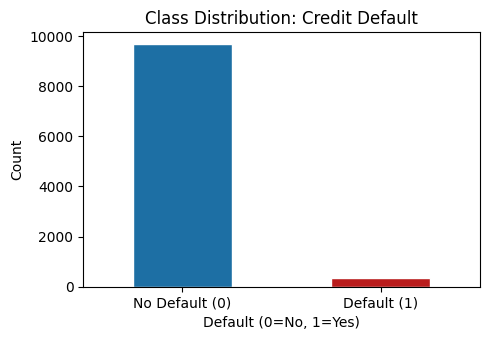

In [13]:
fig, ax = plt.subplots(figsize=(5, 3.5))

df['default'].value_counts().plot(
    kind='bar', ax=ax,
    color=['#1d6fa4', '#b91c1c'],
    edgecolor='white', width=0.5
)
ax.set_title('Class Distribution: Credit Default', fontsize=12)
ax.set_xlabel('Default (0=No, 1=Yes)')
ax.set_ylabel('Count')
ax.set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)
plt.tight_layout()
plt.show()

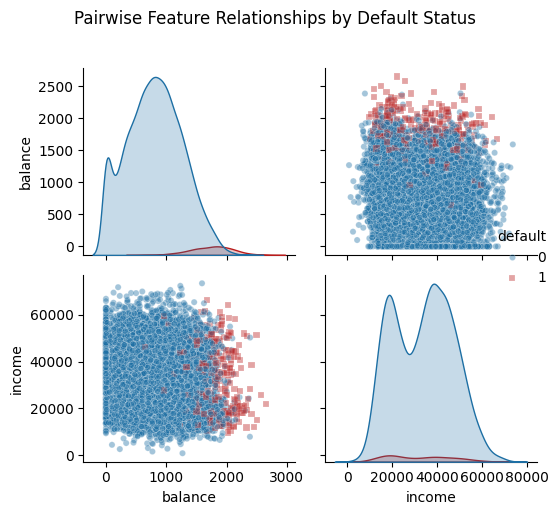

In [14]:
sns.pairplot(
    df,
    vars=['balance', 'income'],
    hue='default',
    palette={0: '#1d6fa4', 1: '#b91c1c'},
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 20},
    markers=['o', 's']
)
plt.suptitle('Pairwise Feature Relationships by Default Status',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numeric features:", numeric_cols.tolist())

Numeric features: ['default', 'balance', 'income']


In [16]:
corr_matrix = df[numeric_cols].corr()
print(corr_matrix)

          default   balance    income
default  1.000000  0.350119 -0.019871
balance  0.350119  1.000000 -0.152243
income  -0.019871 -0.152243  1.000000


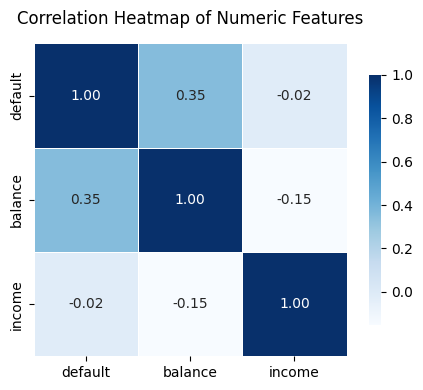

In [17]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.4,
    ax=ax,
    square=True,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=12, pad=14)
plt.tight_layout()
plt.show()

In [18]:
seed(42)

#Seperate features and target
X = df.drop('default', axis=1)
y = df['default']

#Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y # ← NEW: preserves class ratio in both splits
    ) 


In [19]:
print(f"Training set  : {X_train.shape[0]} samples")
print(f"Test set      : {X_test.shape[0]} samples")

print(f"\nTrain default rate: {y_train.mean()*100:.2f}%")
print(f"Test  default rate: {y_test.mean()*100:.2f}%")

Training set  : 8000 samples
Test set      : 2000 samples

Train default rate: 3.33%
Test  default rate: 3.35%


In [20]:
# ── Auto-detect types from training set ──────────────────
numeric_auto     = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_auto = X_train.select_dtypes(include=['object', 'bool']).columns

print("Numeric features:",     numeric_auto.tolist())
print("Categorical features:", categorical_auto.tolist())

Numeric features: ['balance', 'income']
Categorical features: ['student']


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14988\2772122230.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_auto = X_train.select_dtypes(include=['object', 'bool']).columns


In [21]:
# ── Explicitly define feature lists (recommended practice) ─
numeric_features     = ['balance', 'income']
categorical_features = ['student']

In [22]:
# ── Numeric pipeline: impute missing → standardize ────────
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # robust to outliers
    ('scaler',  StandardScaler())
])

In [23]:
# ── Categorical pipeline: impute missing → one-hot encode ─
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(
                    handle_unknown='ignore',
                    sparse_output=False))
])


In [24]:
# ── Combine into ColumnTransformer ────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline,     numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

print("Preprocessor built successfully.")

"""
When using a pipeline:

The imputer and scaler are fitted only on the 'training portion' of each fold.
'The test fold' is never used to compute the imputer’s median or the scaler’s mean and standard deviation.
The test data is only transformed, never used to learn preprocessing parameters.

Because of this, pipelines automatically prevent data leakage.
"""

Preprocessor built successfully.


"\nWhen using a pipeline:\n\nThe imputer and scaler are fitted only on the 'training portion' of each fold.\n'The test fold' is never used to compute the imputer’s median or the scaler’s mean and standard deviation.\nThe test data is only transformed, never used to learn preprocessing parameters.\n\nBecause of this, pipelines automatically prevent data leakage.\n"

In [25]:
from sklearn.tree import DecisionTreeClassifier


pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42
    ))
])
print(pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['balance', 'income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                

In [26]:
# Regression used KFold(n_spliters=5, shuffle=True, random_state=42)
# classification used StratifiedKFold(n_spliters=5, shuffle=True, random_state=42)
# StratifiedKFold guarantees every fold has ~3.3% defaults
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

In [28]:
#param_grid는 “여러 모델을 한 번에 GridSearchCV로 튜닝하기 위한 목록(list)
#param_grid is a list of dictionaries, where each dictionary specifies a set of hyperparameters to tune for a particular model. 
#세 가지 모델(Decision Tree / Random Forest / Bagging)을 각각 테스트해보고, 그중 가장 성능 좋은 모델을 자동으로 골라주는 구조
#Test different models with different hyperparameter combinations in a single GridSearchCV run



param_grid = [
    {
        'classifier': [DecisionTreeClassifier(random_state=42)],
        'classifier__max_depth': [5, 10, 20, 30]
    },
    {
        'classifier': [RandomForestClassifier(random_state=42)],
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [3, 10, 20]
    },
    {
        'classifier': [BaggingClassifier(
            estimator=DecisionTreeClassifier(),
            random_state=42)],
        'classifier__n_estimators': [10, 50, 100]
    }
]

In [29]:
from sklearn.model_selection import GridSearchCV


In [30]:
# ── GridSearchCV ─────────────────────────────────────────
grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid,
    cv         = cv,
    scoring    = 'f1',        # ← was 'neg_mean_squared_error' in regression #becsue of imbalanced dataset, F1 score is more appropriate than accuracy
    n_jobs     = -1,           # use all CPU cores
    verbose    = 1
)

In [31]:
# ── Fit on TRAINING data only ─────────────────────────────
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 13 candidates, totalling 65 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'classifier': [DecisionTreeC...ndom_state=42)], 'classifier__max_depth': [5, 10, ...]}, {'classifier': [RandomForestC...ndom_state=42)], 'classifier__max_depth': [3, 10, ...], 'classifier__n_estimators': [100, 200]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"

In [32]:
# ── Best results ─────────────────────────────────────────
print(f"\nBest parameters : {grid_search.best_params_}")
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")


Best parameters : {'classifier': RandomForestClassifier(random_state=42), 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
Best CV F1 score: 0.4402


In [33]:
best_model = grid_search.best_estimator_ #extract the best model
#_______________________________________________________
best_model.fit(X_train, y_train) #re-fit the best model on the entire training set

y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

print("Best estimator:")
print(grid_search.best_params_)


Best estimator:
{'classifier': RandomForestClassifier(random_state=42), 'classifier__max_depth': 3, 'classifier__n_estimators': 200}


In [35]:
from sklearn.metrics import f1_score,accuracy_score
from imblearn.metrics import geometric_mean_score

In [39]:
err_trian = 1 - accuracy_score(y_train, y_pred_train)
err_test = 1 - accuracy_score(y_test, y_pred_test)
gmean_test = geometric_mean_score(y_test, y_pred_test)
#G-mean is a performance metric in the field of machine learning and specifically in binary classification problems
#The G-mean is a commonly used metric to evaluate the performance of a classifier in imbalanced datasets where one class has a much higher number of samples than the other.
#Best possible score is 1.0, higher value is better. Range = [0, 1]
print("\nTraining Accuracy:", f"{accuracy_score(y_train, y_pred_train)*100:.2f}%")
print("Test Accuracy:", f"{accuracy_score(y_test, y_pred_test)*100:.2f}%")
print("\nTraining Error Rate:", f"{err_trian*100:.2f}%")
print("Test Error Rate:", f"{err_test*100:.2f}%")
print("\nTraining F1 Score:", f"{f1_score(y_train, y_pred_train):.4f}")
print("Test F1 Score:", f"{f1_score(y_test, y_pred_test):.4f}")
print(f"\nTest  G-Mean    : {gmean_test:.4f}")



Training Accuracy: 97.50%
Test Accuracy: 97.15%

Training Error Rate: 2.50%
Test Error Rate: 2.85%

Training F1 Score: 0.5000
Test F1 Score: 0.4466

Test  G-Mean    : 0.5839


In [42]:
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, target_names=['No Default (0)', 'Default (1)']))
conf_matrix = confusion_matrix(y_test, y_pred_test)
print("\nConfusion Matrix:")
print(conf_matrix)


Classification Report:
                precision    recall  f1-score   support

No Default (0)       0.98      0.99      0.99      1933
   Default (1)       0.64      0.34      0.45        67

      accuracy                           0.97      2000
     macro avg       0.81      0.67      0.72      2000
  weighted avg       0.97      0.97      0.97      2000


Confusion Matrix:
[[1920   13]
 [  44   23]]


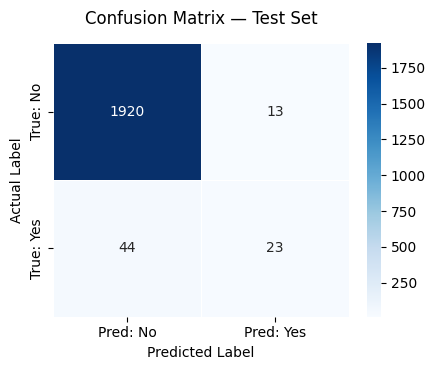

In [43]:
# ── Heatmap visualization ─────────────────────────────────
fig, ax = plt.subplots(figsize=(4.5, 3.8))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax,
    linewidths=0.5,
    xticklabels=['Pred: No', 'Pred: Yes'],
    yticklabels=['True: No', 'True: Yes']
)
ax.set_title('Confusion Matrix — Test Set', fontsize=12, pad=14)
ax.set_ylabel('Actual Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

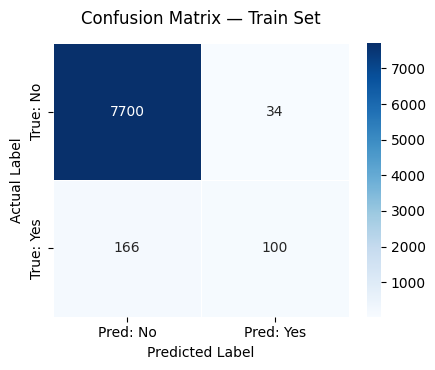

In [45]:
# ── Heatmap visualization ─────────────────────────────────
conf_matrix_train = confusion_matrix(y_train, y_pred_train)

fig, ax = plt.subplots(figsize=(4.5, 3.8))
sns.heatmap(
    conf_matrix_train,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax,
    linewidths=0.5,
    xticklabels=['Pred: No', 'Pred: Yes'],
    yticklabels=['True: No', 'True: Yes']
)
ax.set_title('Confusion Matrix — Train Set', fontsize=12, pad=14)
ax.set_ylabel('Actual Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()